In [1]:
# Installing all AfyaMetrix dependencies directly from Jupyter
# The ! mark tells Jupyter to run this as a terminal command

import sys

!{sys.executable} -m pip install pandas numpy scipy scikit-learn statsmodels plotly openpyxl prophet fastapi uvicorn folium faker python-dotenv requests

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------------

In [4]:
# Geopandas needs special handling on Windows
import sys
!{sys.executable} -m pip install geopandas --extra-index-url https://girder.github.io/large_image_wheels


""""
to be ignored for now
""""

^C


In [11]:
libraries = [
    "pandas", "numpy", "sklearn", "prophet",
    "fastapi", "scipy", "statsmodels",
    "folium", "plotly", "faker", "requests"
]

print("Checking AfyaMetrix dependencies...\n")

all_good = True
for lib in libraries:
    try:
        __import__(lib)
        print(f"  ✅ {lib}")
    except ImportError:
        print(f"  ❌ {lib} — NOT installed")
        all_good = False

print("\n" + ("🚀 All systems go! Ready to build." if all_good else "⚠️  Fix the ❌ libraries before continuing."))

Checking AfyaMetrix dependencies...

  ✅ pandas
  ✅ numpy
  ✅ sklearn
  ✅ prophet
  ✅ fastapi
  ✅ scipy
  ✅ statsmodels
  ✅ folium
  ✅ plotly
  ✅ faker
  ✅ requests

🚀 All systems go! Ready to build.


In [12]:
import os

# Define your project root
project_root = r"C:\Users\hassa\afyametrix"

# All folders we need
folders = [
    "data/raw",          # Raw datasets (WHO, HDX, simulated)
    "data/processed",    # Cleaned, ready-to-use data
    "models/saved",      # Your trained ML models saved as files
    "api",               # FastAPI code
    "notebooks",         # All your Jupyter notebooks
    "utils",             # Helper functions
    "outputs/reports",   # Generated reports and exports
    "outputs/maps",      # Generated heatmap HTML files
]

# Create each folder
for folder in folders:
    full_path = os.path.join(project_root, folder)
    os.makedirs(full_path, exist_ok=True)  
    # exist_ok=True means: don't crash if folder already exists
    print(f"✅ Created: {full_path}")

print("\n🚀 AfyaMetrix project structure ready!")

✅ Created: C:\Users\hassa\afyametrix\data/raw
✅ Created: C:\Users\hassa\afyametrix\data/processed
✅ Created: C:\Users\hassa\afyametrix\models/saved
✅ Created: C:\Users\hassa\afyametrix\api
✅ Created: C:\Users\hassa\afyametrix\notebooks
✅ Created: C:\Users\hassa\afyametrix\utils
✅ Created: C:\Users\hassa\afyametrix\outputs/reports
✅ Created: C:\Users\hassa\afyametrix\outputs/maps

🚀 AfyaMetrix project structure ready!


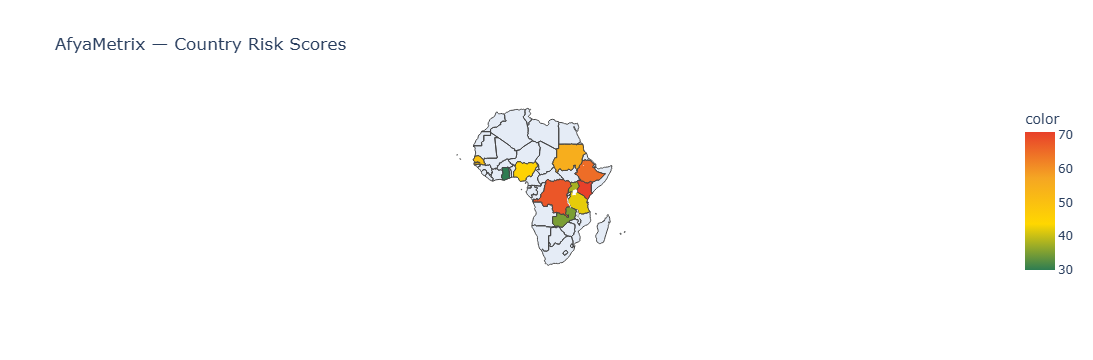

In [3]:
import plotly.express as px

# Test Plotly choropleth - no geopandas needed
fig = px.choropleth(
    locations=["KEN", "NGA", "ETH", "UGA", "TZA", 
               "GHA", "SEN", "COD", "ZMB", "SDN"],
    color=[71, 45, 65, 38, 42, 30, 50, 68, 35, 55],
    color_continuous_scale=["#2E7D52", "#FFD700", "#F5A623", "#E8402A"],
    scope="africa",
    title="AfyaMetrix — Country Risk Scores"
)
fig.show()

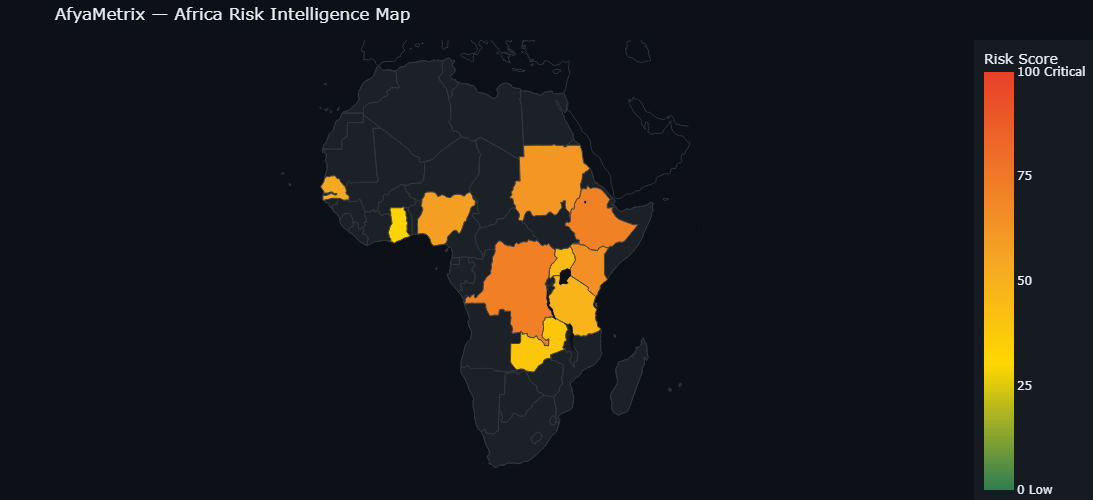

✅ Choropleth map working!


In [7]:
import plotly.express as px
import pandas as pd

test_data = pd.DataFrame({
    'iso_alpha': ['KEN', 'NGA', 'ETH', 'UGA', 'TZA', 
                  'GHA', 'SEN', 'COD', 'ZMB', 'SDN'],
    'country':   ['Kenya', 'Nigeria', 'Ethiopia', 'Uganda', 'Tanzania',
                  'Ghana', 'Senegal', 'DRC', 'Zambia', 'Sudan'],
    'risk_score': [65, 58, 71, 45, 48, 32, 54, 72, 38, 62]
})

fig = px.choropleth(
    test_data,
    locations='iso_alpha',
    color='risk_score',
    hover_name='country',
    hover_data={'risk_score': True, 'iso_alpha': False},
    color_continuous_scale=[
        [0.0,  '#2E7D52'],
        [0.3,  '#FFD700'],
        [0.55, '#F5A623'],
        [1.0,  '#E8402A']
    ],
    range_color=[0, 100],
    scope='africa',
    title='AfyaMetrix — Africa Risk Intelligence Map',
    labels={'risk_score': 'Risk Score'}
)

fig.update_layout(
    paper_bgcolor='#0D1117',
    font_color='#E8EDF3',
    geo=dict(
        bgcolor='#0D1117',
        lakecolor='#0D1117',
        landcolor='#1C2128',
        showframe=True,
        framecolor='#30363D',
        showcoastlines=True,
        coastlinecolor='#30363D',
        showcountries=True,
        countrycolor='#30363D',
        showocean=True,
        oceancolor='#0D1117',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(
        title='Risk Score',
        tickvals=[0, 25, 50, 75, 100],
        ticktext=['0 Low', '25', '50', '75', '100 Critical'],
        bgcolor='#161B22',
        bordercolor='#30363D',
        tickfont=dict(color='#E8EDF3'),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=500
)

fig.show()
print("✅ Choropleth map working!")

In [1]:
import os
import pandas as pd

processed_path = r"C:\Users\hassa\afyametrix\data\processed"

print("Checking Round 1 data files...\n")
required_files = [
    "africa_health_risk_scored.csv",
    "regional_risk_summary.csv",
    "region_clusters.csv",
    "forecast_summary.csv",
    "resource_allocations.csv",
    "cross_border_alerts.csv",
    "data_quality_scores.csv",
    "region_narratives.csv"
]

all_good = True
for f in required_files:
    path = os.path.join(processed_path, f)
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✅ {f:<45} {size:.0f} KB")
    else:
        print(f"  ❌ MISSING: {f}")
        all_good = False

print(f"\n{'✅ All Round 1 files intact — ready to build Round 2' if all_good else '❌ Some files missing — we need to regenerate them first'}")

Checking Round 1 data files...

  ✅ africa_health_risk_scored.csv                 151504 KB
  ✅ regional_risk_summary.csv                     4869 KB
  ✅ region_clusters.csv                           16 KB
  ✅ forecast_summary.csv                          1 KB
  ✅ resource_allocations.csv                      6 KB
  ✅ cross_border_alerts.csv                       1 KB
  ✅ data_quality_scores.csv                       3 KB
  ✅ region_narratives.csv                         11 KB

✅ All Round 1 files intact — ready to build Round 2


In [2]:
libraries = ["pandas", "numpy", "sklearn", "prophet", 
             "fastapi", "scipy", "statsmodels", "plotly", "shap"]

print("Checking libraries...\n")
for lib in libraries:
    try:
        __import__(lib)
        print(f"  ✅ {lib}")
    except ImportError:
        print(f"  ❌ {lib} — needs installing")

Checking libraries...

  ✅ pandas
  ✅ numpy
  ✅ sklearn
  ✅ prophet
  ✅ fastapi
  ✅ scipy
  ✅ statsmodels
  ✅ plotly
  ❌ shap — needs installing


In [3]:
import sys
!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? et